In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model
from keras.datasets import mnist

In [ ]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
class SimpleAutoencoder(Model):
    def __init__(self, latent_dimensions):
        super(SimpleAutoencoder, self).__init__()
        self.encoder = tf.keras.Sequential([
            layers.Input(shape=(28, 28, 1)),
            layers.Flatten(),
            layers.Dense(latent_dimensions, activation='relu'),
        ])

        self.decoder = tf.keras.Sequential([
            layers.Dense(28 * 28, activation='sigmoid'),
            layers.Reshape((28, 28, 1))
        ])

    def call(self, input_data):
        encoded = self.encoder(input_data)
        decoded = self.decoder(encoded)
        return decoded

In [ ]:
latent_dimensions = 64
autoencoder = SimpleAutoencoder(latent_dimensions)
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(x_test, x_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0946 - val_loss: 0.0330
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0295 - val_loss: 0.0209
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0195 - val_loss: 0.0151
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0144 - val_loss: 0.0115
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0112 - val_loss: 0.0093
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0091 - val_loss: 0.0077
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0076 - val_loss: 0.0066
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0066 - val_loss: 0.0059
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0059 - val_loss: 0.0054
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0055 - val_loss: 0.0050


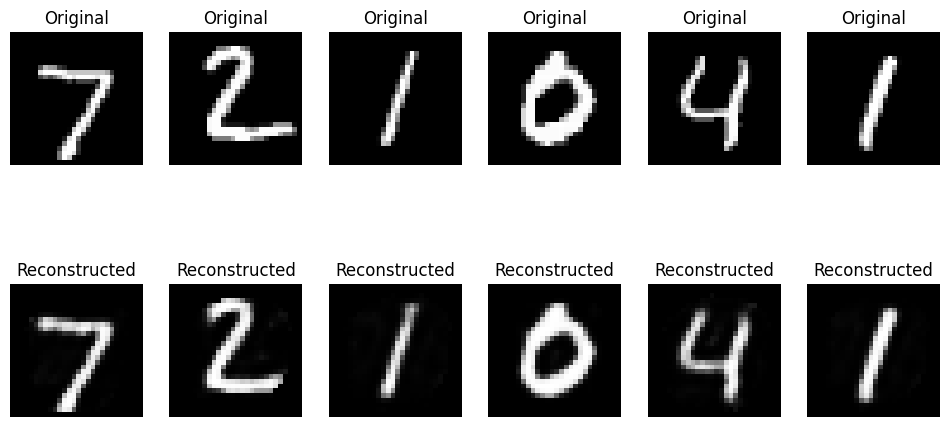

In [ ]:
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

n = 6
plt.figure(figsize=(12, 6))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

In [ ]:
# Calculate entropy loss on test data
def calculate_entropy_loss(autoencoder, data):
    # Get encoded representations
    encoded_imgs = autoencoder.encoder(data).numpy()

    # Calculate probability distribution (normalize activations)
    encoded_flat = encoded_imgs.flatten()
    hist, _ = np.histogram(encoded_flat, bins=50, density=True)

    # Add small epsilon to avoid log(0)
    hist = hist + 1e-10
    hist = hist / np.sum(hist)

    # Calculate entropy
    entropy = -np.sum(hist * np.log2(hist))

    return entropy

# Calculate and print entropy loss
train_entropy = calculate_entropy_loss(autoencoder, x_train[:1000])
test_entropy = calculate_entropy_loss(autoencoder, x_test[:1000])

print(f"Entropy of latent representations:")
print(f"Training data: {train_entropy:.4f} bits")
print(f"Test data: {test_entropy:.4f} bits")
print(f"Maximum possible entropy (uniform distribution): {np.log2(50):.4f} bits")

Entropy of latent representations:
Training data: 4.0737 bits
Test data: 3.9452 bits
Maximum possible entropy (uniform distribution): 5.6439 bits


**U-Net**

Generating challenging dataset...
Training data shape: (1600, 128, 128, 1)
Training masks shape: (1600, 128, 128, 1)
Test data shape: (400, 128, 128, 1)


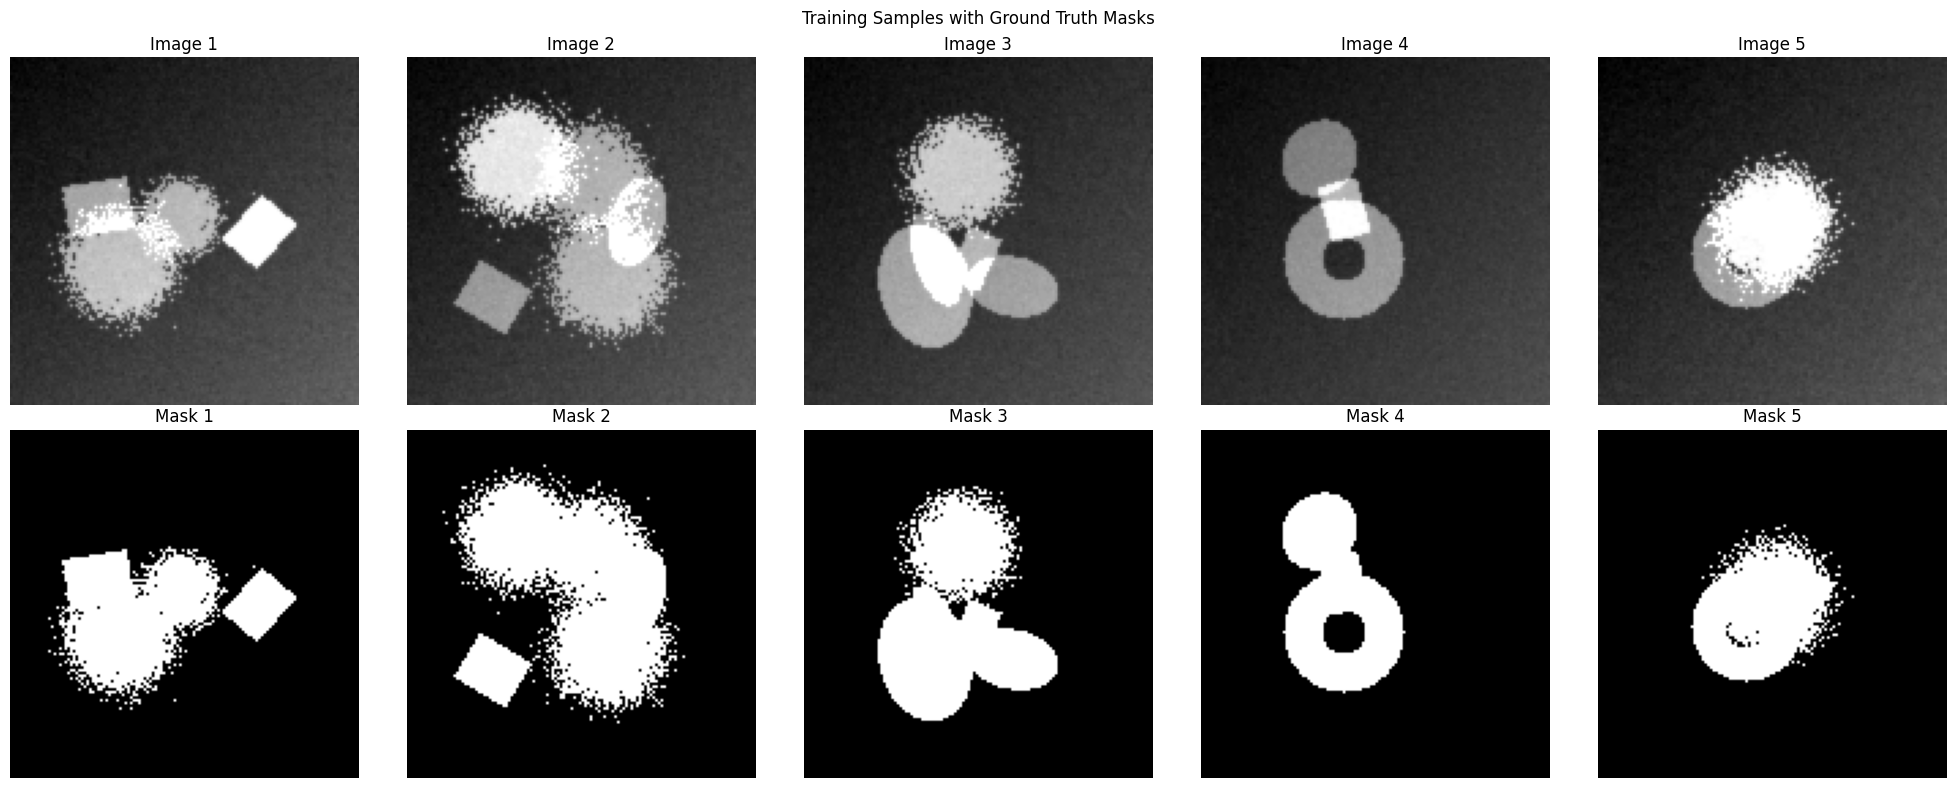

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
import cv2
from scipy import ndimage

# Generate more challenging synthetic dataset
def generate_challenging_data(num_samples=2000, img_size=128):
    images = []
    masks = []

    for _ in range(num_samples):
        # Create blank image with gradient background
        y, x = np.mgrid[:img_size, :img_size]
        background = (x / img_size + y / img_size) / 2 * 0.3
        img = background.copy()
        mask = np.zeros((img_size, img_size))

        # Random number of objects (2-5)
        num_objects = np.random.randint(2, 6)

        for obj_idx in range(num_objects):
            # Random shape parameters
            shape_type = np.random.choice(['ellipse', 'rectangle', 'donut', 'blob'])
            center_x = np.random.randint(30, img_size-30)
            center_y = np.random.randint(30, img_size-30)

            if shape_type == 'ellipse':
                # Ellipse with random orientation
                major_axis = np.random.randint(15, 30)
                minor_axis = np.random.randint(8, 20)
                angle = np.random.randint(0, 180)

                # Create ellipse
                y_grid, x_grid = np.ogrid[:img_size, :img_size]
                x_rot = (x_grid - center_x) * np.cos(np.radians(angle)) + (y_grid - center_y) * np.sin(np.radians(angle))
                y_rot = -(x_grid - center_x) * np.sin(np.radians(angle)) + (y_grid - center_y) * np.cos(np.radians(angle))
                shape_mask = (x_rot**2 / major_axis**2 + y_rot**2 / minor_axis**2) <= 1

            elif shape_type == 'donut':
                # Donut shape (circle with hole)
                outer_radius = np.random.randint(20, 30)
                inner_radius = np.random.randint(8, 15)
                y_grid, x_grid = np.ogrid[:img_size, :img_size]
                dist = np.sqrt((x_grid - center_x)**2 + (y_grid - center_y)**2)
                shape_mask = (dist <= outer_radius) & (dist >= inner_radius)

            elif shape_type == 'blob':
                # Irregular blob using Gaussian blob
                y_grid, x_grid = np.mgrid[:img_size, :img_size]
                blob = np.exp(-((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * (np.random.randint(10, 20)**2)))
                blob += np.random.normal(0, 0.1, blob.shape)
                shape_mask = blob > 0.5
            else:
                # Rectangle with random orientation
                width = np.random.randint(15, 30)
                height = np.random.randint(10, 25)
                angle = np.random.randint(0, 180)

                # Create rotated rectangle
                y_grid, x_grid = np.mgrid[:img_size, :img_size]
                x_rot = (x_grid - center_x) * np.cos(np.radians(angle)) + (y_grid - center_y) * np.sin(np.radians(angle))
                y_rot = -(x_grid - center_x) * np.sin(np.radians(angle)) + (y_grid - center_y) * np.cos(np.radians(angle))
                shape_mask = (np.abs(x_rot) <= width/2) & (np.abs(y_rot) <= height/2)

            # Add overlapping regions with different intensities
            intensity = np.random.uniform(0.6, 1.0)

            # Handle overlapping regions (take max for mask, additive for image)
            if obj_idx > 0:
                # For overlapping areas, mask should be 1 if any object covers it
                mask = np.maximum(mask, shape_mask.astype(float) * 1.0)

                # For image, overlapping areas have higher intensity
                overlap = (mask > 0) & shape_mask
                img[overlap] = np.minimum(img[overlap] + intensity * 0.5, 1.0)
                img[shape_mask & (mask == 0)] = intensity
            else:
                mask = shape_mask.astype(float)
                img[shape_mask] = intensity

        # Add noise and blur
        img += np.random.normal(0, 0.02, img.shape)
        img = ndimage.gaussian_filter(img, sigma=0.5)

        # Add random brightness/contrast variations
        img = img * np.random.uniform(0.8, 1.2) + np.random.uniform(-0.1, 0.1)
        img = np.clip(img, 0, 1)

        # Ensure mask is binary
        mask = (mask > 0.5).astype(np.float32)

        # Add small random holes in mask (imperfect ground truth)
        if np.random.random() > 0.7:
            hole_size = np.random.randint(3, 7)
            hole_y = np.random.randint(0, img_size - hole_size)
            hole_x = np.random.randint(0, img_size - hole_size)
            mask[hole_y:hole_y+hole_size, hole_x:hole_x+hole_size] = 0

        images.append(img.reshape(img_size, img_size, 1))
        masks.append(mask.reshape(img_size, img_size, 1))

    return np.array(images), np.array(masks)

# Generate data
print("Generating challenging dataset...")
x, y = generate_challenging_data(2000, img_size=128)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"Training data shape: {x_train.shape}")
print(f"Training masks shape: {y_train.shape}")
print(f"Test data shape: {x_test.shape}")

# Visualize samples
n = 5 # Use n=5 for consistent visualization output
plt.figure(figsize=(20, 8))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(128, 128), cmap='gray')
    plt.title(f'Image {i+1}')
    plt.axis('off')

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(y_train[i].reshape(128, 128), cmap='gray')
    plt.title(f'Mask {i+1}')
    plt.axis('off')
plt.suptitle('Training Samples with Ground Truth Masks')
plt.tight_layout()
plt.show()

In [ ]:
# Deeper U-Net for 128x128 images
def unet_deeper(input_size=(128, 128, 1)):
    inputs = layers.Input(input_size)

    # Encoder
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)
    pool1 = layers.Dropout(0.2)(pool1)

    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)
    pool2 = layers.Dropout(0.2)(pool2)

    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)
    pool3 = layers.Dropout(0.2)(pool3)

    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv4)
    conv4 = layers.BatchNormalization()(conv4)
    pool4 = layers.MaxPooling2D(pool_size=(2, 2))(conv4)
    pool4 = layers.Dropout(0.2)(pool4)

    # Bridge
    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(conv5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.Dropout(0.3)(conv5)

    # Decoder
    up6 = layers.UpSampling2D(size=(2, 2))(conv5)
    concat6 = layers.Concatenate()([up6, conv4])
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(concat6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same')(conv6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.Dropout(0.2)(conv6)

    up7 = layers.UpSampling2D(size=(2, 2))(conv6)
    concat7 = layers.Concatenate()([up7, conv3])
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(concat7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same')(conv7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.Dropout(0.2)(conv7)

    up8 = layers.UpSampling2D(size=(2, 2))(conv7)
    concat8 = layers.Concatenate()([up8, conv2])
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(concat8)
    conv8 = layers.BatchNormalization()(conv8)
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same')(conv8)
    conv8 = layers.BatchNormalization()(conv8)
    conv8 = layers.Dropout(0.2)(conv8)

    up9 = layers.UpSampling2D(size=(2, 2))(conv8)
    concat9 = layers.Concatenate()([up9, conv1])
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(concat9)
    conv9 = layers.BatchNormalization()(conv9)
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same')(conv9)
    conv9 = layers.BatchNormalization()(conv9)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(conv9)

    model = Model(inputs, outputs)
    return model

# Create and compile model
unet = unet_deeper()
unet.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
             loss='binary_crossentropy',
             metrics=['accuracy', keras.metrics.MeanIoU(num_classes=2)])

unet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        640 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ dropout_1[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_5[0][0]  

 Total params: 31,401,345 (119.79 MB)

 Trainable params: 31,389,569 (119.74 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [ ]:
# Callbacks
callbacks = [
    keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=8, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint('best_unet_model.h5', save_best_only=True, verbose=1)
]

# Train
history = unet.fit(
    x_train, y_train,
    epochs=2, # Set to 2 for quick demonstration. Increase for better results.
    batch_size=16,  # Smaller batch size due to larger images
    validation_data=(x_test, y_test),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.9391 - loss: 0.1780 - mean_io_u: 0.5446
Epoch 1: val_loss improved from inf to 0.69501, saving model to best_unet_model.h5


100/100 ━━━━━━━━━━━━━━━━━━━━ 100s 425ms/step - accuracy: 0.9395 - loss: 0.1770 - mean_io_u: 0.5458 - val_accuracy: 0.8342 - val_loss: 0.6950 - val_mean_io_u: 0.4147 - learning_rate: 0.0010
Epoch 2/2
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - accuracy: 0.9998 - loss: 0.0089 - mean_io_u: 0.8774
Epoch 2: val_loss did not improve from 0.69501
100/100 ━━━━━━━━━━━━━━━━━━━━ 27s 274ms/step - accuracy: 0.9998 - loss: 0.0089 - mean_io_u: 0.8775 - val_accuracy: 0.8294 - val_loss: 1.4545 - val_mean_io_u: 0.4147 - learning_rate: 0.0010


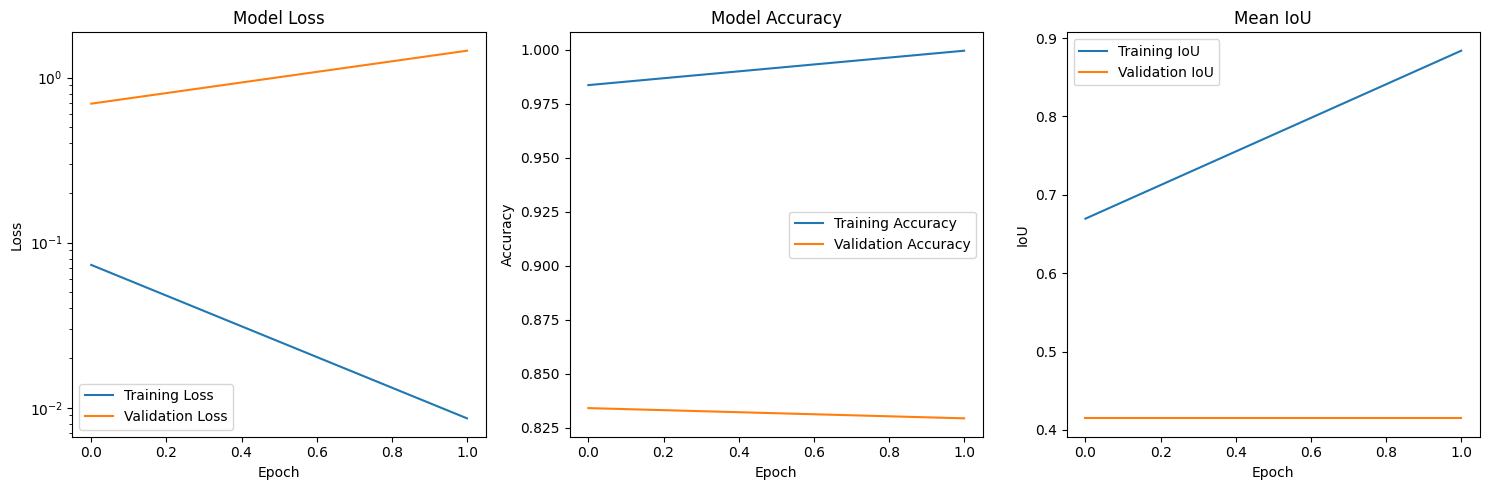


Final Test IoU Score: 0.0278


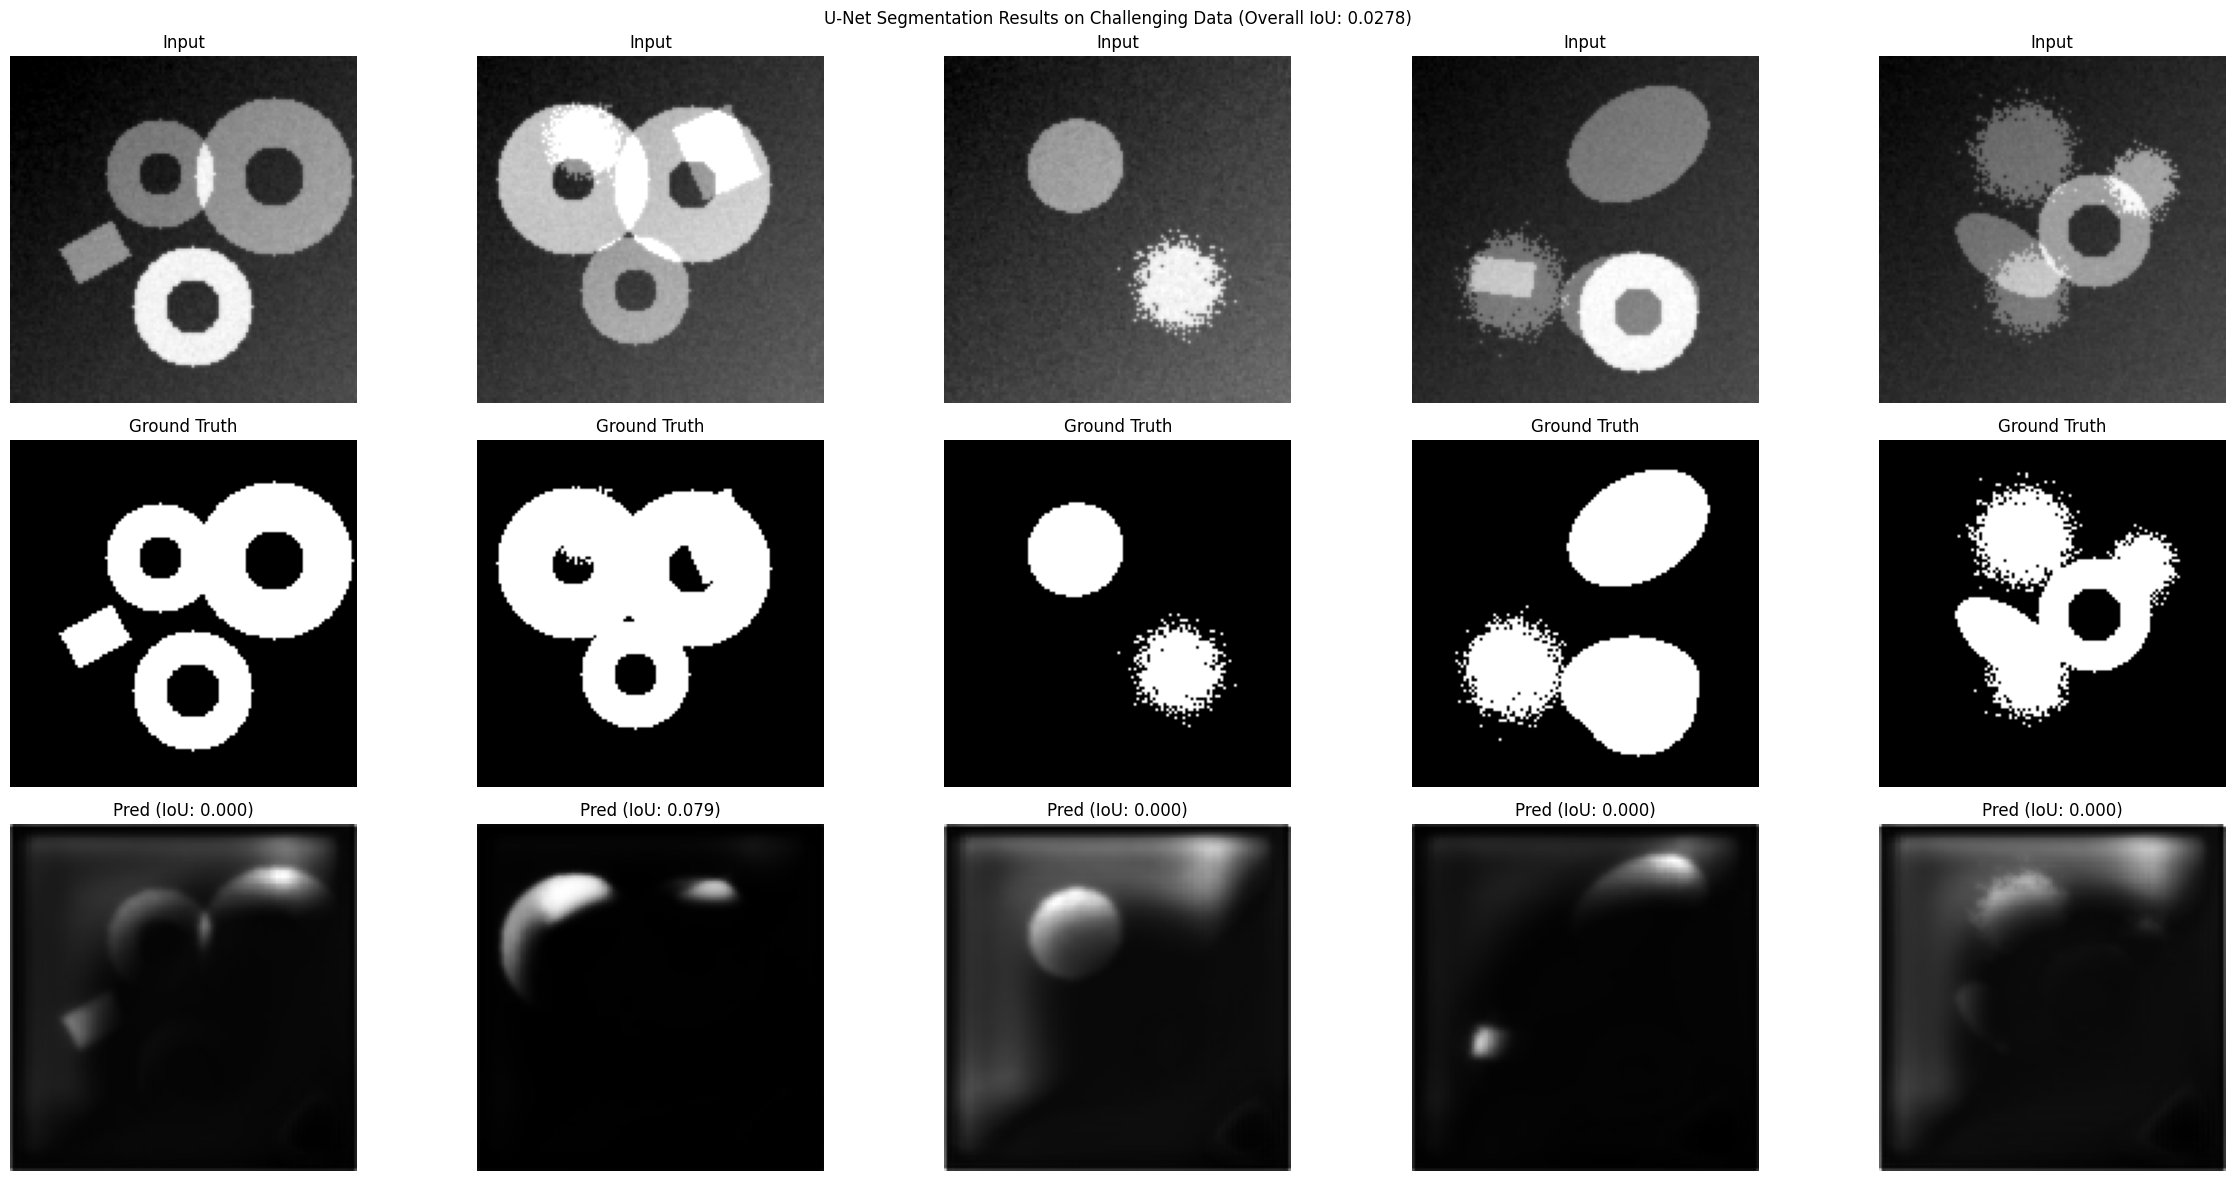

In [ ]:
# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.yscale('log')

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['mean_io_u'], label='Training IoU')
plt.plot(history.history['val_mean_io_u'], label='Validation IoU')
plt.title('Mean IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate final IoU
from sklearn.metrics import jaccard_score

y_pred = unet.predict(x_test, verbose=0)
y_pred_binary = (y_pred > 0.5).astype(np.int32)
y_test_flat = y_test.reshape(-1)
y_pred_flat = y_pred_binary.reshape(-1)

iou = jaccard_score(y_test_flat, y_pred_flat)
print(f"\nFinal Test IoU Score: {iou:.4f}")

# Visualize results including challenging cases
n = 5 # Use n=5 for consistent visualization output
plt.figure(figsize=(24, 12))

for i in range(n):
    idx = np.random.randint(len(x_test))

    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[idx].reshape(128, 128), cmap='gray')
    plt.title('Input')
    plt.axis('off')

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(y_test[idx].reshape(128, 128), cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(y_pred[idx].reshape(128, 128), cmap='gray')
    sample_iou = jaccard_score(y_test[idx].reshape(-1), (y_pred[idx] > 0.5).reshape(-1))
    plt.title(f'Pred (IoU: {sample_iou:.3f})')
    plt.axis('off')

plt.suptitle(f'U-Net Segmentation Results on Challenging Data (Overall IoU: {iou:.4f})')
plt.tight_layout()
plt.show()

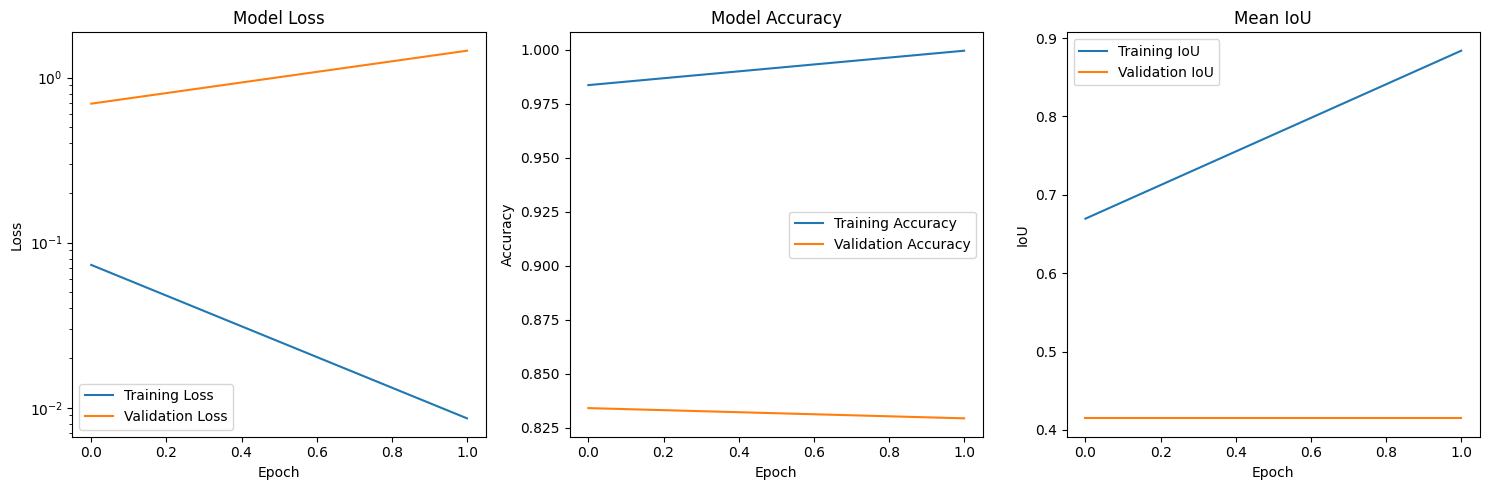


Final Test IoU Score: 0.0278


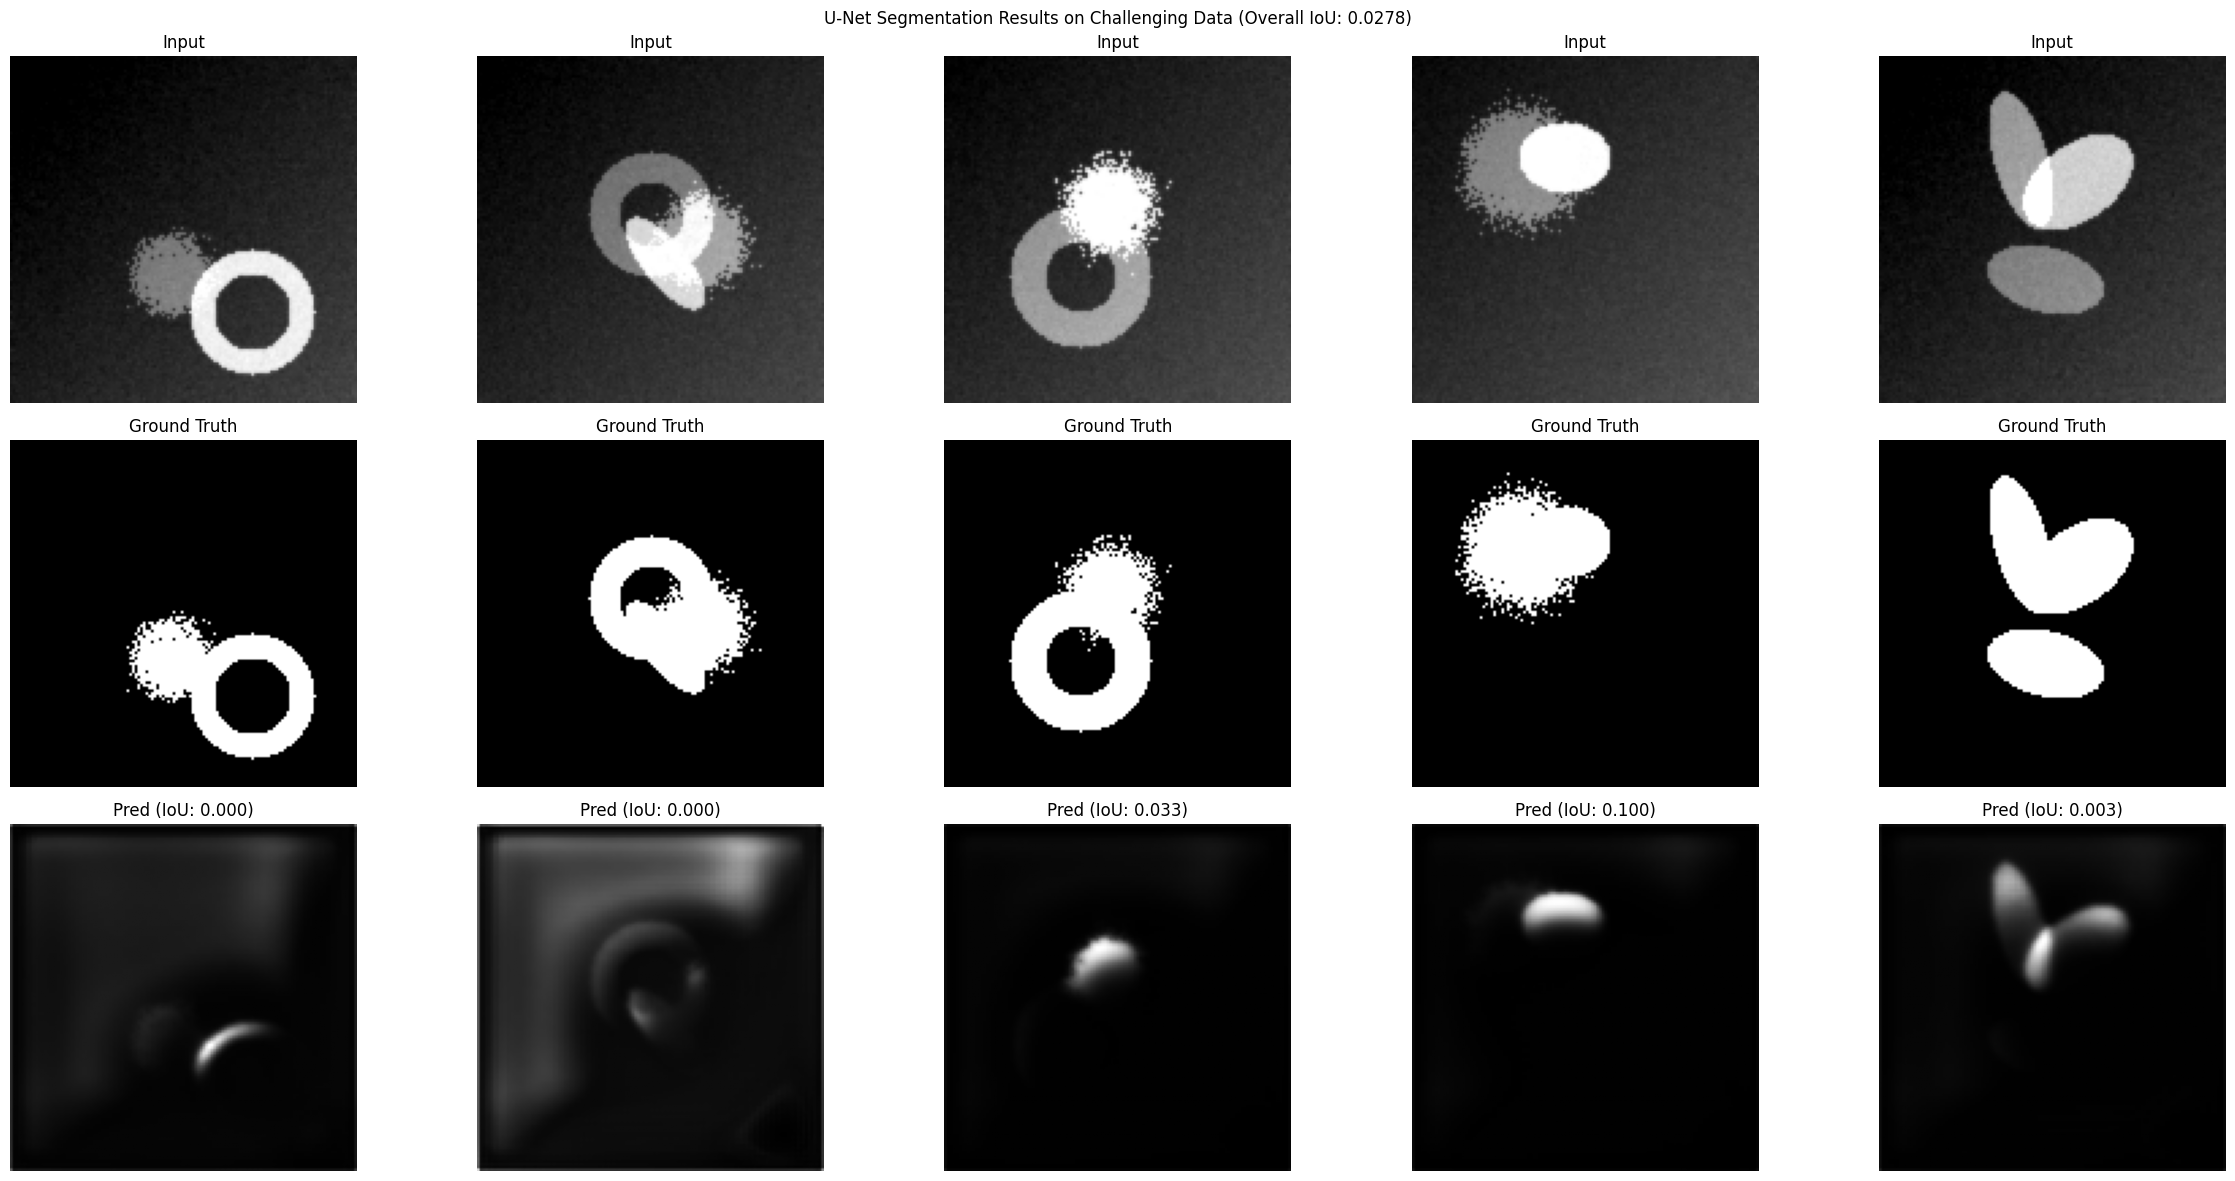

In [ ]:
# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.yscale('log')

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history['mean_io_u'], label='Training IoU')
plt.plot(history.history['val_mean_io_u'], label='Validation IoU')
plt.title('Mean IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate final IoU
from sklearn.metrics import jaccard_score

y_pred = unet.predict(x_test, verbose=0)
y_pred_binary = (y_pred > 0.5).astype(np.int32)
y_test_flat = y_test.reshape(-1)
y_pred_flat = y_pred_binary.reshape(-1)

iou = jaccard_score(y_test_flat, y_pred_flat)
print(f"\nFinal Test IoU Score: {iou:.4f}")

# Visualize results including challenging cases
n = 5 # Use n=5 for consistent visualization output
plt.figure(figsize=(24, 12))

for i in range(n):
    idx = np.random.randint(len(x_test))

    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[idx].reshape(128, 128), cmap='gray')
    plt.title('Input')
    plt.axis('off')

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(y_test[idx].reshape(128, 128), cmap='gray')
    plt.title('Ground Truth')
    plt.axis('off')

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(y_pred[idx].reshape(128, 128), cmap='gray')
    sample_iou = jaccard_score(y_test[idx].reshape(-1), (y_pred[idx] > 0.5).reshape(-1))
    plt.title(f'Pred (IoU: {sample_iou:.3f})')
    plt.axis('off')

plt.suptitle(f'U-Net Segmentation Results on Challenging Data (Overall IoU: {iou:.4f})')
plt.tight_layout()
plt.show()